In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12,6)

matches = pd.read_csv('data/cleaned_matches.csv')
deliveries = pd.read_csv('data/cleaned_deliveries.csv')

### Top Run Scorers

In [11]:
batting = pd.DataFrame()

batting['runs'] = (
    deliveries.groupby('batter')
    ['batsman_runs']
    .sum()
)

batting['balls'] = (
    deliveries.groupby('batter')
    .size()
)

batting['outs'] = (
    deliveries[
        deliveries['player_dismissed'].notna()
    ]
    .groupby('player_dismissed')
    .size()
)

batting = batting.fillna(0)

batting = batting[
    batting['outs'] > 0
]

batting['average'] = (
    batting['runs']
    / batting['outs']
)

batting['strike_rate'] = (
    batting['runs']
    / batting['balls']
) * 100

batting = batting[
    batting['runs'] >= 1000
]

In [12]:
top_runs = batting.sort_values(
    'runs',
    ascending=False
).head(10)

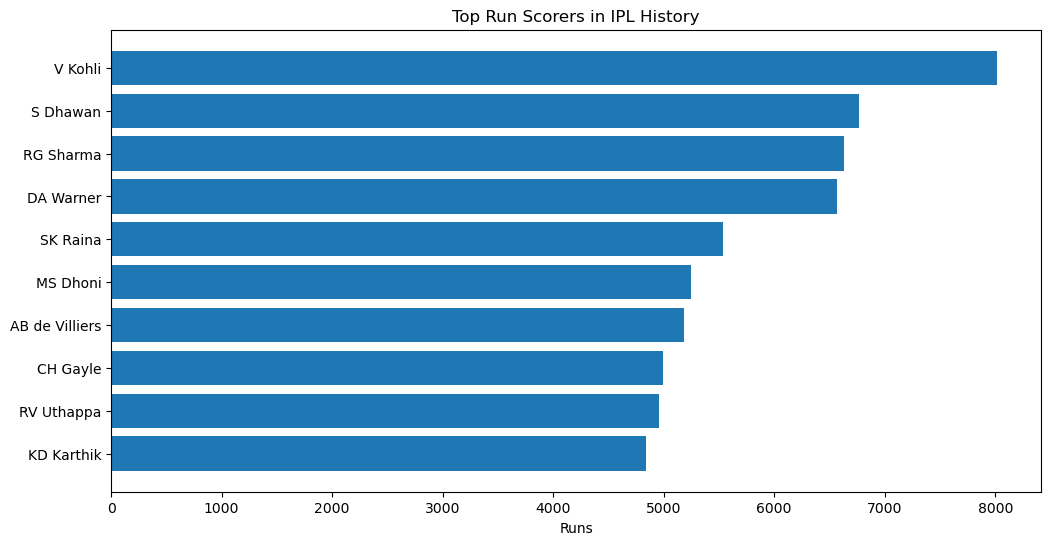

In [13]:
plt.figure(figsize=(12,6))

plt.barh(
    top_runs.index[::-1],
    top_runs['runs'][::-1]
)

plt.xlabel("Runs")

plt.title(
    "Top Run Scorers in IPL History"
)

plt.show()

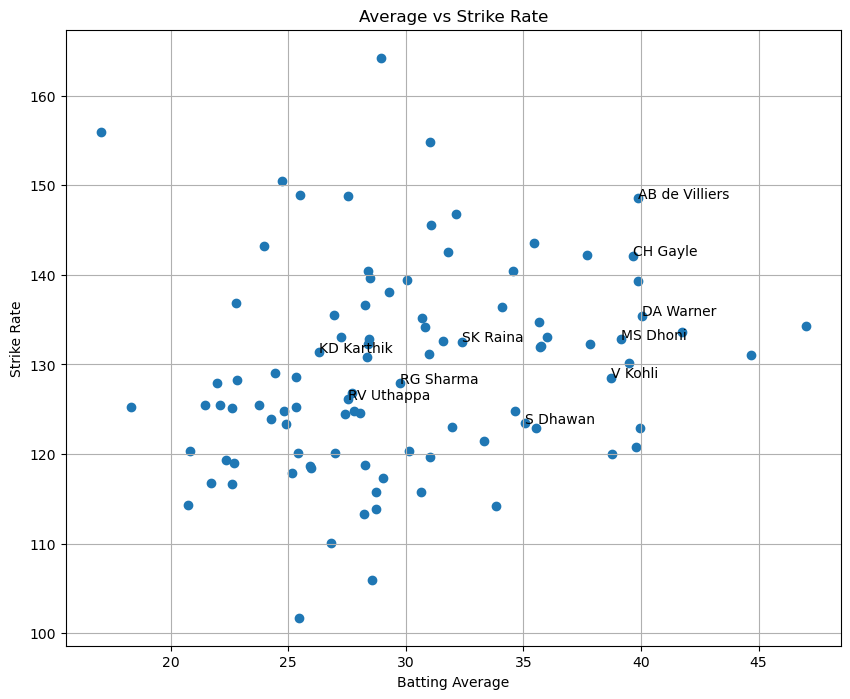

In [14]:
plt.figure(figsize=(10,8))

plt.scatter(
    batting['average'],
    batting['strike_rate']
)

top_players = batting.nlargest(
    10,
    'runs'
)

for player in top_players.index:

    plt.annotate(
        player,
        (
            batting.loc[player,'average'],
            batting.loc[player,'strike_rate']
        )
    )

plt.xlabel("Batting Average")

plt.ylabel("Strike Rate")

plt.title(
    "Average vs Strike Rate"
)

plt.grid()

plt.show()

In [15]:
batting['runs_score'] = (
    batting['runs']
    / batting['runs'].max()
)

batting['avg_score'] = (
    batting['average']
    / batting['average'].max()
)

batting['sr_score'] = (
    batting['strike_rate']
    / batting['strike_rate'].max()
)

batting['batting_impact'] = (
      batting['runs_score'] * 0.4
    + batting['avg_score'] * 0.3
    + batting['sr_score'] * 0.3
)

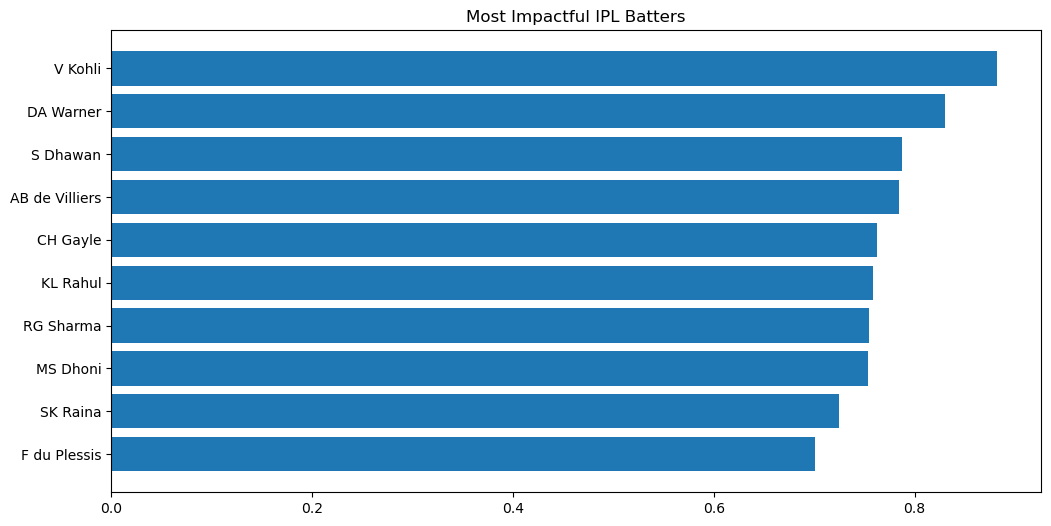

In [18]:
top_batters = batting.sort_values(
    'batting_impact', 
    ascending=False    
).head(10)         
plt.figure(figsize=(12,6))

plt.barh(
    top_batters.index[::-1],
    top_batters['batting_impact'][::-1]
)

plt.title(
    "Most Impactful IPL Batters"
)

plt.show()


In [19]:
bowling = pd.DataFrame()

bowling['wickets'] = (
    deliveries[
        deliveries['dismissal_kind'].notna()
    ]
    .groupby('bowler')
    .size()
)

bowling['runs_conceded'] = (
    deliveries.groupby('bowler')
    ['total_runs_ball']
    .sum()
)

bowling['balls'] = (
    deliveries.groupby('bowler')
    .size()
)

bowling = bowling.fillna(0)

bowling['overs'] = (
    bowling['balls']
    / 6
)

bowling['economy'] = (
    bowling['runs_conceded']
    / bowling['overs']
)

bowling = bowling[
    bowling['balls'] >= 300
]

In [21]:
top_wickets = bowling.sort_values(
    'wickets',
    ascending=False
).head(10)

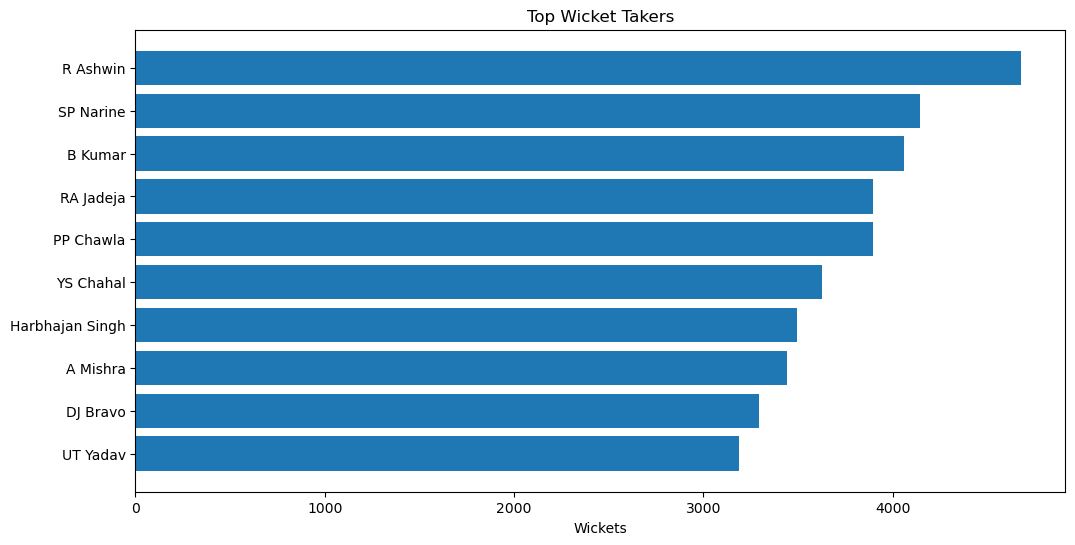

In [22]:
plt.figure(figsize=(12,6))

plt.barh(
    top_wickets.index[::-1],
    top_wickets['wickets'][::-1]
)

plt.xlabel("Wickets")

plt.title(
    "Top Wicket Takers"
)

plt.show()

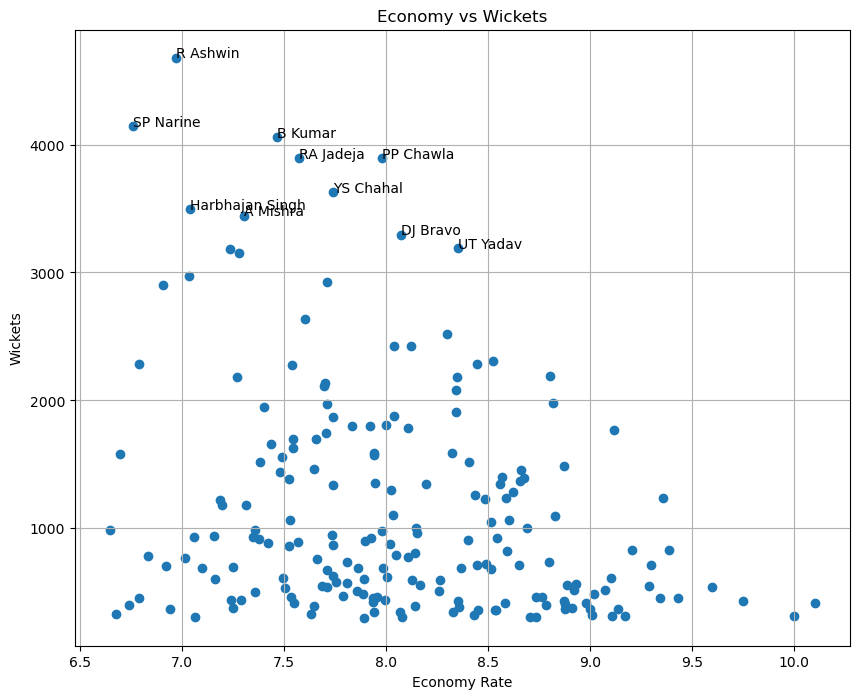

In [23]:
plt.figure(figsize=(10,8))

plt.scatter(
    bowling['economy'],
    bowling['wickets']
)

top_bowlers = bowling.nlargest(
    10,
    'wickets'
)

for player in top_bowlers.index:

    plt.annotate(
        player,
        (
            bowling.loc[player,'economy'],
            bowling.loc[player,'wickets']
        )
    )

plt.xlabel("Economy Rate")

plt.ylabel("Wickets")

plt.title(
    "Economy vs Wickets"
)

plt.grid()

plt.show()

In [24]:
death = deliveries[
    deliveries['is_death_over'] == 1
]

death_wickets = (
    death[
        death['dismissal_kind'].notna()
    ]
    .groupby('bowler')
    .size()
    .sort_values(
        ascending=False
    )
    .head(10)
)

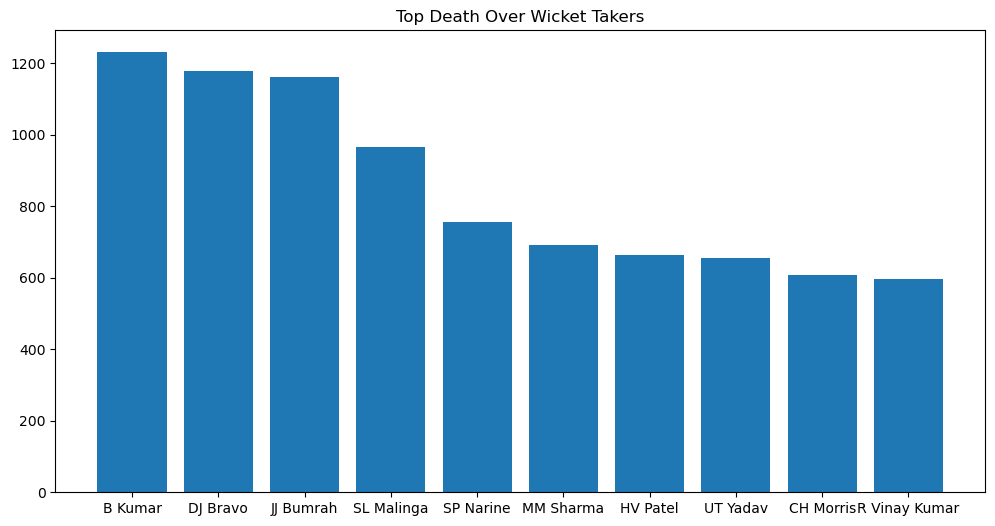

In [28]:
plt.figure(figsize=(12,6))

plt.bar(
    death_wickets.index,
    death_wickets.values
)

plt.title(
    "Top Death Over Wicket Takers"
)

plt.show()

In [29]:
impact = pd.DataFrame()

impact['runs'] = batting['runs']

impact['wickets'] = bowling['wickets']

impact = impact.fillna(0)

impact['run_score'] = (
    impact['runs']
    / impact['runs'].max()
)

impact['wicket_score'] = (
    impact['wickets']
    / impact['wickets'].max()
)

impact['impact_score'] = (
      impact['run_score'] * 0.6
    + impact['wicket_score'] * 0.4
)

In [30]:
top_impact = impact.sort_values(
    'impact_score',
    ascending=False
).head(10)

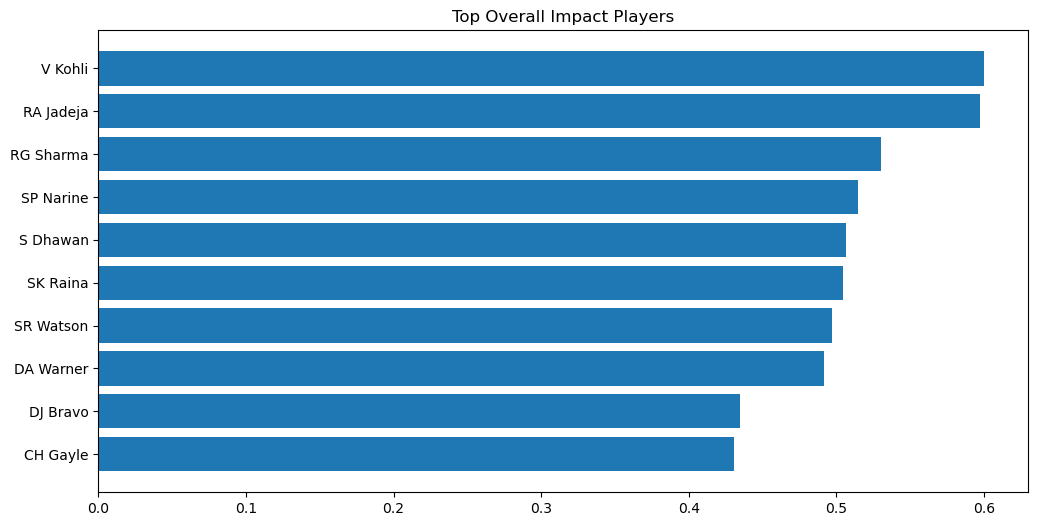

In [31]:
plt.figure(figsize=(12,6))

plt.barh(
    top_impact.index[::-1],
    top_impact['impact_score'][::-1]
)

plt.title(
    "Top Overall Impact Players"
)

plt.show()

In [33]:
top_runs

,runs,balls,outs,average,strike_rate
batter,,,,,
V Kohli,8014,6236,207.0,38.714976,128.511867
S Dhawan,6769,5483,193.0,35.072539,123.454313
RG Sharma,6630,5183,223.0,29.730942,127.918194
DA Warner,6567,4849,164.0,40.042683,135.429986
SK Raina,5536,4177,171.0,32.374269,132.535312
MS Dhoni,5243,3947,134.0,39.126866,132.835065
AB de Villiers,5181,3487,130.0,39.853846,148.580442
CH Gayle,4997,3516,126.0,39.658730,142.121729
RV Uthappa,4954,3927,180.0,27.522222,126.152279


In [34]:

top_batters


,runs,balls,outs,average,strike_rate,runs_score,avg_score,sr_score,batting_impact
batter,,,,,,,,,
V Kohli,8014,6236,207.0,38.714976,128.511867,1.000000,0.823723,0.782538,0.881878
DA Warner,6567,4849,164.0,40.042683,135.429986,0.819441,0.851972,0.824664,0.830767
S Dhawan,6769,5483,193.0,35.072539,123.454313,0.844647,0.746224,0.751741,0.787248
AB de Villiers,5181,3487,130.0,39.853846,148.580442,0.646494,0.847954,0.904740,0.784406
CH Gayle,4997,3516,126.0,39.658730,142.121729,0.623534,0.843803,0.865412,0.762178
KL Rahul,4689,3578,105.0,44.657143,131.050866,0.585101,0.950152,0.797999,0.758486
RG Sharma,6630,5183,223.0,29.730942,127.918194,0.827302,0.632573,0.778923,0.754370
MS Dhoni,5243,3947,134.0,39.126866,132.835065,0.654230,0.832487,0.808863,0.754097
SK Raina,5536,4177,171.0,32.374269,132.535312,0.690791,0.688814,0.807038,0.725072


In [35]:

top_wickets


,wickets,runs_conceded,balls,overs,economy
bowler,,,,,
R Ashwin,4679,5435,4679,779.833333,6.969438
SP Narine,4146,4672,4146,691.000000,6.761216
B Kumar,4060,5051,4060,676.666667,7.464532
RA Jadeja,3895,4917,3895,649.166667,7.574326
PP Chawla,3895,5179,3895,649.166667,7.977920
YS Chahal,3628,4681,3628,604.666667,7.741455
Harbhajan Singh,3496,4101,3496,582.666667,7.038330
A Mishra,3444,4193,3444,574.000000,7.304878
DJ Bravo,3296,4436,3296,549.333333,8.075243


In [36]:
death_wickets


bowler
B Kumar          1231
DJ Bravo         1179
JJ Bumrah        1163
SL Malinga        965
SP Narine         755
MM Sharma         692
HV Patel          664
UT Yadav          656
CH Morris         609
R Vinay Kumar     598
dtype: int64

In [37]:
top_impact

,runs,wickets,run_score,wicket_score,impact_score
batter,,,,,
V Kohli,8014,0.0,1.000000,0.000000,0.600000
RA Jadeja,2959,3895.0,0.369229,0.939460,0.597321
RG Sharma,6630,349.0,0.827302,0.084178,0.530052
SP Narine,1534,4146.0,0.191415,1.000000,0.514849
S Dhawan,6769,0.0,0.844647,0.000000,0.506788
SK Raina,5536,930.0,0.690791,0.224313,0.504200
SR Watson,3880,2137.0,0.484153,0.515437,0.496666
DA Warner,6567,0.0,0.819441,0.000000,0.491665
DJ Bravo,1560,3296.0,0.194659,0.794983,0.434789
